##### problem Statement & Goal: To classify 150 iris flowers into three species (Setosa, Versicolor, or Virginica) based on four numerical measurements of their sepals and petals.

### Part 0: Imports

In [65]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

### Part 1: Data Loading, Preprocessing & Overview

In [48]:
iris = load_iris(as_frame=True)
df = iris.frame

df.isnull().sum()

# Overview the dataset
df.info()
df.describe()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


### Part 2: Exploratory Data Analysis (EDA)

<Axes: >

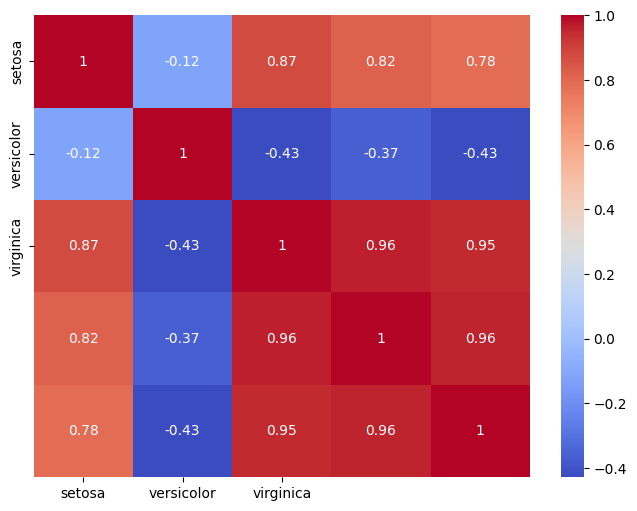

In [62]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', xticklabels=iris.target_names, yticklabels=iris.target_names)

### Part 3: Test & Train Data Definition

In [55]:
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target

# Split Data (training data 80%, testing data 20%)
X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, test_size=0.2, random_state=42)

### Part 4: Training Model

In [56]:
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


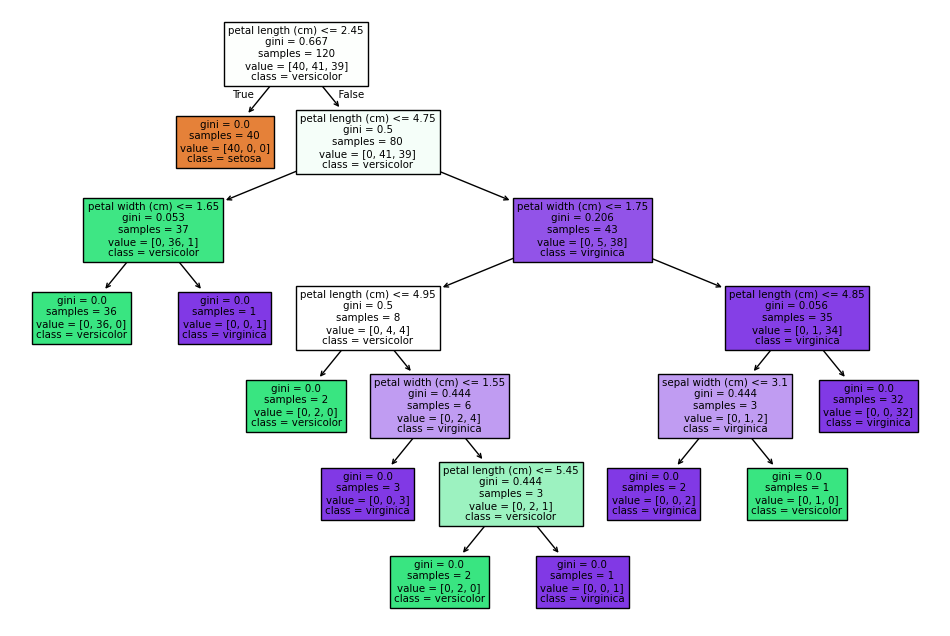

In [57]:
plt.figure(figsize=(12, 8))
plot_tree(tree, feature_names=iris.feature_names, class_names=iris.target_names, filled=True)
plt.show()

### Part 5: Model Evaluation

In [79]:
def model_evaluation(model, X_train, y_train, X_test, y_test):
    print(f"Overfit Tree Train Acc: {accuracy_score(y_train, model.predict(X_train)):.2f}")
    print(f"Overfit Tree Test Acc:  {accuracy_score(y_test, model.predict(X_test)):.2f}")
    print("-" * 30)
    print("Classification Report:\n", classification_report(y_test, model.predict(X_test), target_names=iris.target_names))
    print("Overall Accuracy:\n", accuracy_score(y_test, model.predict(X_test)))
    print("Confusion Matrix:\n", confusion_matrix(y_test, model.predict(X_test)))    

In [80]:
model_evaluation(tree, X_train, y_train, X_test, y_test)

Overfit Tree Train Acc: 1.00
Overfit Tree Test Acc:  1.00
------------------------------
Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Overall Accuracy:
 1.0
Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [81]:
pruned_tree = DecisionTreeClassifier(max_depth=3, min_samples_leaf=5, random_state=42)
pruned_tree.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


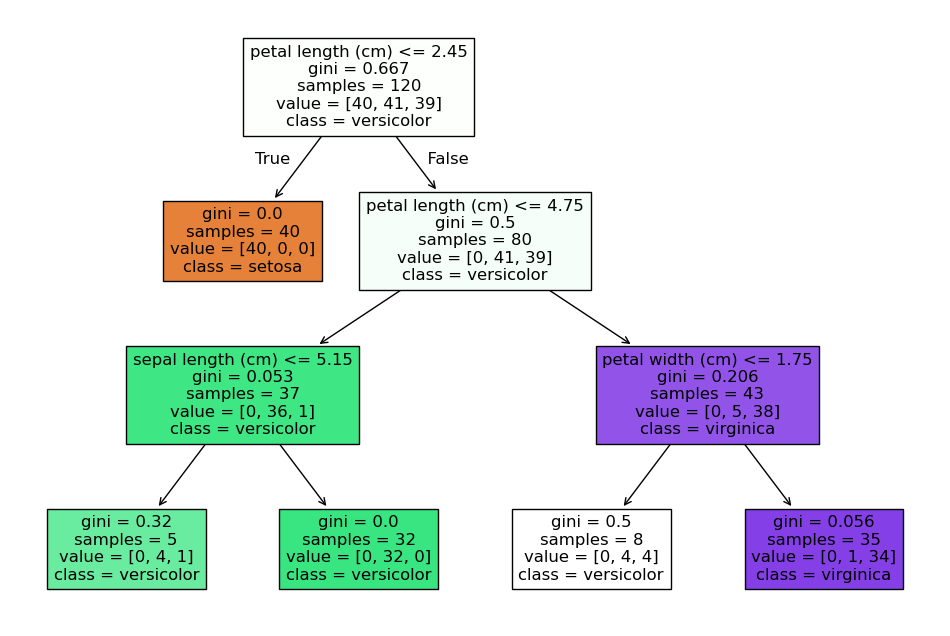

In [82]:
plt.figure(figsize=(12, 8))
plot_tree(pruned_tree, feature_names=iris.feature_names, class_names=iris.target_names, filled=True)
plt.show()

In [84]:
model_evaluation(pruned_tree, X_train, y_train, X_test, y_test)

Overfit Tree Train Acc: 0.95
Overfit Tree Test Acc:  1.00
------------------------------
Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Overall Accuracy:
 1.0
Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
